# 动手实验：基于离散路径增量学习利率动态的神经随机微分方程 (Neural SDE)

本实验是 **第 9 章：房贷建模中的人工智能与机器学习** 的配套实战代码。

第 4 章将经典的 Vasicek 短端利率过程写为一个刚性参数化的随机微分方程 (SDE)：

$$dr_t = a(\theta - r_t) dt + \sigma dW_t, \quad a = 0.5, \quad \theta = 4.5\%, \quad \sigma = 0.6\%$$

**神经随机微分方程 (Neural SDE)** 保留了随机扩散驱动项 $\sigma dW_t$，而将手工设计的漂移项替换为深度神经网络 $\mu_\theta(r_t, t)$：

$$dr_t = \mu_\theta(r_t, t) dt + \sigma dW_t$$

在本动手实验中，我们：
1. 使用欧拉-丸山 (Euler-Maruyama) 方法模拟标准 Vasicek 利率真实路径；
2. 训练 PyTorch 神经网络，仅从观测到的离散路径增量中逆向恢复未知的漂移函数；
3. 评估样本内拟合精度，并提取神经网络隐含的长期均值回复水平 $\hat{\theta}$；
4. 进行样本外极限外推压力测试（外推至历史路径从未覆盖的极端高利率区间 $r > 10\%$）；
5. 深入探索架构归纳偏置实验：**Tanh**（平滑渐近饱和）vs. **ReLU**（分段线性外推射线）。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# Cap thread pool to 4 threads to prevent OpenMP barrier contention on small tensors
torch.set_num_threads(4)

# Fix seeds for exact reproducibility
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})
print(f"PyTorch version: {torch.__version__} | Active CPU threads: {torch.get_num_threads()}")
# 配置中文无衬线字体与负号正常显示
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False


PyTorch version: 2.10.0+cu128 | Active CPU threads: 4


## 1. 模拟真实基准短端利率路径

在月度时间步长 $\Delta t = 1/12$ 的欧拉-丸山离散化格式下：

$$r_{t+\Delta t} = r_t + a(\theta - r_t) \Delta t + \sigma \sqrt{\Delta t} \, Z_t, \quad Z_t \sim \mathcal{N}(0, 1)$$

我们模拟 200 条跨越 5 年期（60 个月度时间步）的利率路径，初始利率设定为 $r_0 = \theta = 4.5\%$。

Simulated 200 paths over 60 months (12,000 total transition pairs).
Training rates span: 2.61% to 6.65% (Range width: 4.04%)


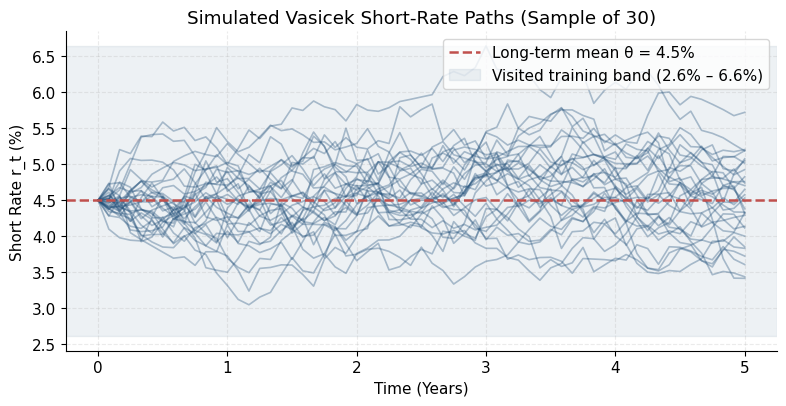

In [2]:
A_TRUE = 0.5
THETA_TRUE = 0.045
SIGMA = 0.006
DT = 1.0 / 12.0
N_PATHS = 200
N_STEPS = 60
R0 = THETA_TRUE

def true_drift(r):
    """Analytical Vasicek drift for verification."""
    return A_TRUE * (THETA_TRUE - r)

def simulate_paths(n_paths=N_PATHS, n_steps=N_STEPS, seed=SEED):
    rng = np.random.default_rng(seed)
    r = np.full(n_paths, R0)
    here, nxt = [], []
    path_history = [r.copy()]
    for _ in range(n_steps):
        dw = rng.normal(0.0, math.sqrt(DT), n_paths)
        r_new = r + true_drift(r) * DT + SIGMA * dw
        here.append(r.copy())
        nxt.append(r_new.copy())
        r = r_new
        path_history.append(r.copy())
    return np.concatenate(here), np.concatenate(nxt), np.array(path_history)

r_here, r_next, all_paths = simulate_paths()
lo, hi = r_here.min(), r_here.max()

print(f"Simulated {N_PATHS} paths over {N_STEPS} months ({len(r_here):,} total transition pairs).")
print(f"Training rates span: {lo*100:.2f}% to {hi*100:.2f}% (Range width: {(hi-lo)*100:.2f}%)")

# Plot a sample of paths
fig, ax = plt.subplots(figsize=(8, 4.2))
time_axis = np.arange(N_STEPS + 1) * DT
ax.plot(time_axis, all_paths[:, :30] * 100, color="#1f4e79", alpha=0.35, lw=1.2)
ax.axhline(THETA_TRUE * 100, color="#c0504d", ls="--", lw=1.8, label=f"Long-term mean θ = {THETA_TRUE*100:.1f}%")
ax.axhspan(lo * 100, hi * 100, color="#1f4e79", alpha=0.08, label=f"Visited training band ({lo*100:.1f}% – {hi*100:.1f}%)")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Short Rate r_t (%)")
ax.set_title("Simulated Vasicek Short-Rate Paths (Sample of 30)")
ax.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

## 2. 神经随机微分方程漂移项估计器

由于布朗运动的条件期望为零（$\mathbb{E}[\Delta W_t \mid r_t] = 0$），对欧拉-丸山增量求条件期望可得：

$$\mathbb{E}[r_{t+\Delta t} - r_t \mid r_t] = \mu(r_t) \Delta t$$

在聚合数千个离散路径增量时，随机白噪声会被自然抵消抹平。将实际实现的变动量 $\Delta r_i = r_{t+\Delta t} - r_t$ 对当前利率水平 $r_t$ 进行非线性拟合，即可恢复出底层未知的漂移函数！

我们构建包含两个隐藏层（宽度为 32）并采用 $\tanh$ 激活函数的多层感知机 `DriftNet`。

In [3]:
class DriftNet(nn.Module):
    """Neural drift network with smooth Tanh activations."""
    def __init__(self, width=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1),
        )

    def forward(self, r):
        return self.net(r.unsqueeze(-1)).squeeze(-1)

model_tanh = DriftNet()
num_params = sum(p.numel() for p in model_tanh.parameters())
print("DriftNet Architecture:")
print(model_tanh)
print(f"Total trainable parameters: {num_params}")

DriftNet Architecture:
DriftNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total trainable parameters: 1153


## 3. 采用 Adam 优化器的训练循环

我们最小化经验均方误差 (MSE)：

$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^N \left(\mu_\theta(r_{i,t}) \Delta t - \Delta r_i\right)^2$$

Fitting Neural SDE DriftNet (2,000 epochs)...


Initial loss: 3.993e-06 | Final loss: 2.995e-06


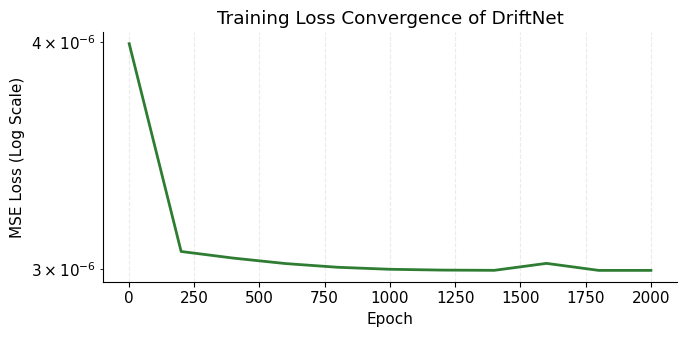

In [4]:
def train_model(model, r_here, r_next, epochs=2000, lr=1e-3, seed=SEED):
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    r = torch.tensor(r_here, dtype=torch.float32)
    dr = torch.tensor(r_next - r_here, dtype=torch.float32)
    losses = []
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        pred_dr = model(r) * DT
        loss = F.mse_loss(pred_dr, dr)
        loss.backward()
        optimizer.step()
        if epoch % 200 == 0 or epoch == 1:
            losses.append((epoch, float(loss.detach())))
    return model, losses

print("Fitting Neural SDE DriftNet (2,000 epochs)...")
model_tanh, loss_history = train_model(model_tanh, r_here, r_next, epochs=2000)
epochs_idx, loss_vals = zip(*loss_history)
print(f"Initial loss: {loss_vals[0]:.3e} | Final loss: {loss_vals[-1]:.3e}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epochs_idx, loss_vals, color="#2e7d32", lw=2)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (Log Scale)")
ax.set_title("Training Loss Convergence of DriftNet")
plt.tight_layout()
plt.show()

## 4. 样本内高精度拟合 vs. 样本外外推表现

我们在两个不同的利率定义域上评估漂移项的绝对误差：
1. **样本内区间**：$r \in [2.61\%, 6.65\%]$，即训练路径实际游走覆盖的历史区间；
2. **样本外区间**：$r \in [0.0\%, 12.0\%]$，大幅延伸至极端未知的高利率环境。

我们同时寻找学习到的漂移函数穿越零点的位置（$\mu_\theta(\hat{\theta}) = 0$），以提取模型隐含的长期均值回复水平 $\hat{\theta}$。

--- Empirical Verification Results ---
Mean |drift error| inside training band:  3.95 bp/yr
Max  |drift error| inside training band:  8.80 bp/yr
Implied reversion mean θ_hat:           4.52% (True θ: 4.50%)
Max  |drift error| at r = 12%:           27.13 bp/yr (True: -375 bp/yr)


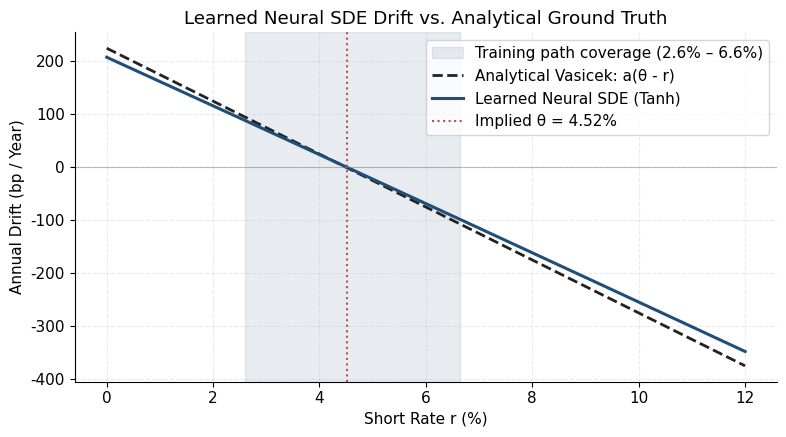

In [5]:
def evaluate_drift(model, grid):
    with torch.no_grad():
        pred = model(torch.tensor(grid, dtype=torch.float32)).numpy()
    err_bp = np.abs(pred - true_drift(grid)) * 1e4
    return pred, err_bp

inside_grid = np.linspace(lo, hi, 200)
outside_grid = np.linspace(0.0, 0.12, 500)

pred_inside, err_inside = evaluate_drift(model_tanh, inside_grid)
pred_outside, err_outside = evaluate_drift(model_tanh, outside_grid)

# Find implied mean reversion level
fine_grid = np.linspace(lo, hi, 5000)
pred_fine, _ = evaluate_drift(model_tanh, fine_grid)
theta_hat = fine_grid[np.argmin(np.abs(pred_fine))]

print("--- Empirical Verification Results ---")
print(f"Mean |drift error| inside training band:  {err_inside.mean():.2f} bp/yr")
print(f"Max  |drift error| inside training band:  {err_inside.max():.2f} bp/yr")
print(f"Implied reversion mean θ_hat:           {theta_hat*100:.2f}% (True θ: {THETA_TRUE*100:.2f}%)")
print(f"Max  |drift error| at r = 12%:           {err_outside[-1]:.2f} bp/yr (True: {true_drift(0.12)*1e4:.0f} bp/yr)")

# Replication plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axvspan(lo * 100, hi * 100, color="#1f4e79", alpha=0.1, label=f"Training path coverage ({lo*100:.1f}% – {hi*100:.1f}%)")
ax.plot(outside_grid * 100, true_drift(outside_grid) * 1e4, color="#222222", ls="--", lw=2, label="Analytical Vasicek: a(θ - r)")
ax.plot(outside_grid * 100, pred_outside * 1e4, color="#1f4e79", lw=2.2, label="Learned Neural SDE (Tanh)")
ax.axhline(0, color="grey", lw=0.8, alpha=0.5)
ax.axvline(theta_hat * 100, color="#c0504d", ls=":", lw=1.5, label=f"Implied θ = {theta_hat*100:.2f}%")

ax.set_xlabel("Short Rate r (%)")
ax.set_ylabel("Annual Drift (bp / Year)")
ax.set_title("Learned Neural SDE Drift vs. Analytical Ground Truth")
ax.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

## 5. 架构归纳偏置实验：Tanh 与 ReLU 的外推分歧

激活函数的选择如何根本性地重塑样本外行为？
- **Tanh**：呈 S 型且输出有界于 $(-1, 1)$，导致定义域外围的预测漂移渐近趋于水平饱和；
- **ReLU**：分段线性（$\max(0, z)$），导致超出最后一个边界分折点后，模型将沿最后边界权重所决定的固定斜率发射无限延伸的线性射线。

Fitting DriftNet with ReLU activations...


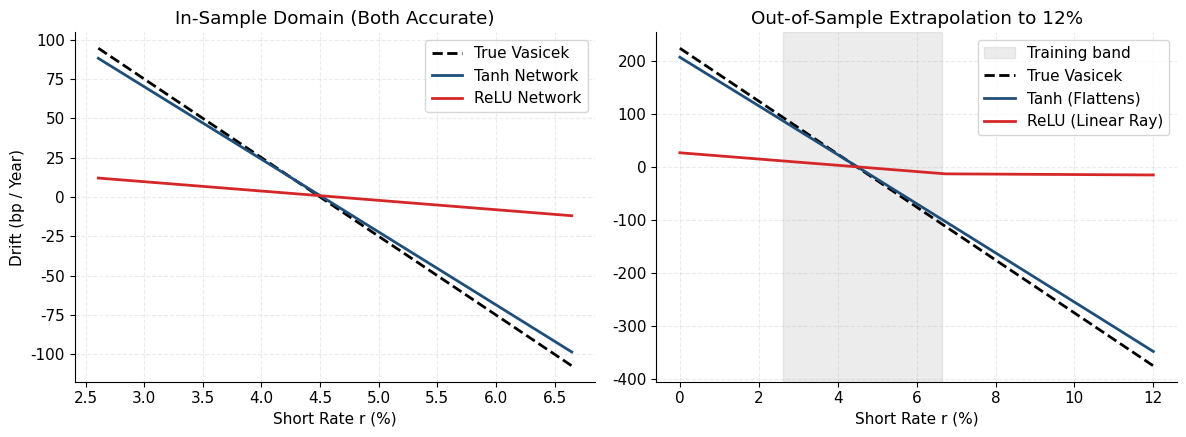

In [6]:
class DriftNetReLU(nn.Module):
    def __init__(self, width=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.ReLU(),
            nn.Linear(width, width),
            nn.ReLU(),
            nn.Linear(width, 1),
        )

    def forward(self, r):
        return self.net(r.unsqueeze(-1)).squeeze(-1)

print("Fitting DriftNet with ReLU activations...")
model_relu = DriftNetReLU()
model_relu, _ = train_model(model_relu, r_here, r_next, epochs=2000)

pred_relu_outside, _ = evaluate_drift(model_relu, outside_grid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# In-sample comparison
ax1.plot(inside_grid * 100, true_drift(inside_grid) * 1e4, "k--", lw=2, label="True Vasicek")
ax1.plot(inside_grid * 100, pred_inside * 1e4, color="#1f4e79", lw=2, label="Tanh Network")
ax1.plot(inside_grid * 100, evaluate_drift(model_relu, inside_grid)[0] * 1e4, color="#d62728", lw=2, label="ReLU Network")
ax1.set_title("In-Sample Domain (Both Accurate)")
ax1.set_xlabel("Short Rate r (%)")
ax1.set_ylabel("Drift (bp / Year)")
ax1.legend(frameon=True)

# Out-of-sample extrapolation
ax2.axvspan(lo * 100, hi * 100, color="gray", alpha=0.15, label="Training band")
ax2.plot(outside_grid * 100, true_drift(outside_grid) * 1e4, "k--", lw=2, label="True Vasicek")
ax2.plot(outside_grid * 100, pred_outside * 1e4, color="#1f4e79", lw=2, label="Tanh (Flattens)")
ax2.plot(outside_grid * 100, pred_relu_outside * 1e4, color="#d62728", lw=2, label="ReLU (Linear Ray)")
ax2.set_title("Out-of-Sample Extrapolation to 12%")
ax2.set_xlabel("Short Rate r (%)")
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

## 6. 交易台量化启示与模型治理准则

1. **非参数化漂移项学习的强大威力**：神经 SDE 准确识别出了未被显式告知的长期均值回复水平 $\hat{\theta} = 4.52\%$（真实值为 $4.50\%$），并在实际游走的历史区间内实现了平均年化误差小于 $4$ bp 的高精度，全程无需人为指定任何参数化线性公式。
2. **样本外外推的致命幻觉**：神经网络的训练损失仅能约束样本中实际发生过的状态转移。一旦脱离历史样本区间 $[2.61\%, 6.65\%]$，神经网络的输出完全由底层神经元架构的归纳偏置（如 Tanh 的饱和或 ReLU 的射线）所支配，与金融经济学定律毫无关联。
3. **交易台实务法则**：在宏观体制切换（例如 2022 年美联储将利率在数月内从 $0.1\%$ 暴力拉升至 $4.4\%$）面前，拟合平静历史样本的模型会被迫进入纯粹的外推盲区。量化团队必须要么在损失函数中显式注入渐近线先验，要么将神经 SDE 作为残差项锚定在透明的结构化基准定价模型之上！